In [ ]:
import time
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import jax
import optax
from orbax.checkpoint import PyTreeCheckpointer
from flax.training.train_state import TrainState

from lotf import LOTF_PATH
from lotf.algos import bptt
from lotf.envs import HoveringStateEnv
from lotf.envs.wrappers import MinMaxObservationWrapper, LogWrapper, VecEnv
from lotf.modules import MLP
from lotf.objects import Quadrotor

# Training a State-Based Hovering Policy With BPTT

## 1. Seed

In [2]:
seed = 0
key = jax.random.key(seed)
key_init, key_bptt = jax.random.split(key, 2)

## 2. Define Simulation Dynamics Config and Training Params

In [3]:
# simulation dynamics config
sim_dyn_config = {
    "use_high_fidelity": False,          # whether to use high-fidelity dynamics in forward simulation
    "use_forward_residual": False,       # whether to use residual dynamics in forward simulation
}

# training parameters
num_envs = 200
max_epochs = 200

## 3. Create Quadrotor Object and Simulation Environment

In [4]:
# simulation parameters
sim_dt = 0.02
max_sim_time = 3.0

# quadrotor object
quad_obj = Quadrotor.from_name("example_quad", sim_dyn_config)

# simulation environment
env = HoveringStateEnv(
    max_steps_in_episode=int(max_sim_time / sim_dt),
    dt=sim_dt,
    delay=0.04,
    yaw_scale=1.0,
    pitch_roll_scale=0.1,
    velocity_std=0.1,
    omega_std=0.1,
    quad_obj=quad_obj,
    reward_sharpness=3.0,
    action_penalty_weight=0.5,
    margin=0.5,
    hover_target=[1.5, 0.0, 1.5],
)

# apply min-max observation wrapper
env = MinMaxObservationWrapper(env)

# get dimensions
action_dim = env.action_space.shape[0]
obs_dim = env.observation_space.shape[0]

# apply additional wrappers
env = LogWrapper(env)
env = VecEnv(env)

print("====== env info ======")
print(f"action_dim: {action_dim}")
print(f"obs_dim: {obs_dim}")
print(f"target hover goal: {env.goal}")

====== env info ======
action_dim: 4
obs_dim: 27
target hover goal: [1.5 0.  1.5]


## 4. Create Policy Network, Optimizer, and Train State

In [5]:
# policy network and init parameters
policy_net = MLP(
    [obs_dim, 512, 512, action_dim],
    initial_scale=0.01,
    action_bias=env.hovering_action,
)
policy_params = policy_net.initialize(key_init)

# optimizer
scheduler = optax.cosine_decay_schedule(5e-3, max_epochs)
tx = optax.adam(scheduler)

# train state object
train_state = TrainState.create(
    apply_fn=policy_net.apply, params=policy_params, tx=tx
)

## 5. Load Dummy Residual Dynamics Network Parameters

In [6]:
# NOTE: Since we are training a base policy, we do not actually use the residual dynamics for forward sim or backprop
# However, we simply load a dummy residual dynamics model to satisfy the simulation environment requirements

path = LOTF_PATH + "/../checkpoints/residual_dynamics/dummy_params"
ckptr = PyTreeCheckpointer()
dummy_residual_params = ckptr.restore(path)

/home/dimitria/venvs/diff-sim-env/lib/python3.12/site-packages/orbax/checkpoint/type_handlers.py:1330: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


## 6. Train

In [7]:
# intialize environments
key_bptt, key_ = jax.random.split(key_bptt)
key_reset = jax.random.split(key_, num_envs)
init_env_state, init_obs = env.reset(key_reset, None)

# training loop
time_start = time.time()
res_dict = bptt.train(
    env,
    init_env_state,
    init_obs,
    train_state,
    num_epochs=max_epochs,
    num_steps_per_epoch=env.max_steps_in_episode,
    num_envs=num_envs,
    res_model_params=dummy_residual_params,
    key=key_bptt,
)
time_train_compile = time.time() - time_start
print(f"Compile + Training time: {time_train_compile}")

Episode: 0, Grad max: 0.1943
Episode: 0, Loss: 10.46
Episode: 10, Grad max: 0.8177
Episode: 10, Loss: 10.50
Episode: 20, Grad max: 1.7834
Episode: 20, Loss: 3.12
Episode: 30, Grad max: 0.8469
Episode: 30, Loss: 1.73
Episode: 40, Grad max: 0.5275
Episode: 40, Loss: 1.19
Episode: 50, Grad max: 0.1509
Episode: 50, Loss: 1.00
Episode: 60, Grad max: 0.0953
Episode: 60, Loss: 0.89
Episode: 70, Grad max: 0.0789
Episode: 70, Loss: 0.83
Episode: 80, Grad max: 0.0248
Episode: 80, Loss: 0.80
Episode: 90, Grad max: 0.0137
Episode: 90, Loss: 0.81
Episode: 100, Grad max: 0.0166
Episode: 100, Loss: 0.79
Episode: 110, Grad max: 0.0118
Episode: 110, Loss: 0.75
Episode: 120, Grad max: 0.0073
Episode: 120, Loss: 0.74
Episode: 130, Grad max: 0.0097
Episode: 130, Loss: 0.77
Episode: 140, Grad max: 0.0126
Episode: 140, Loss: 0.76
Episode: 150, Grad max: 0.0095
Episode: 150, Loss: 0.76
Episode: 160, Grad max: 0.0061
Episode: 160, Loss: 0.76
Episode: 170, Grad max: 0.0035
Episode: 170, Loss: 0.76
Episode: 180

## 7. Plot Rewards

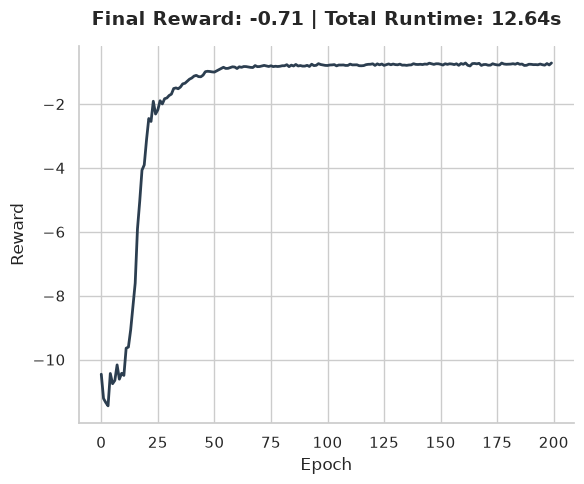

In [8]:
losses = res_dict['metrics']
returns = -losses

sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 5))
plt.plot(returns, color='#2c3e50', linewidth=2)
plt.title(f"Final Reward: {returns[-1]:.2f} | Total Runtime: {time_train_compile:.2f}s", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Reward", fontsize=12)
plt.tight_layout()
sns.despine()
plt.show()

## 8. (Optional) Save the Policy Checkpoint

In [ ]:
policy_name = "my_state_hovering_params"

path = LOTF_PATH + "/../checkpoints/policy/" + policy_name
ckptr = PyTreeCheckpointer()
trained_policy_params = res_dict["runner_state"].train_state.params
ckptr.save(path, trained_policy_params)
print(f"Policy saved successfully!")

ValueError: Destination /home/dimitria/PhD_codes/learning_on_the_fly/lotf/../checkpoints/policy/my_state_hovering_params already exists.

: 